
Reading folder:
H:\FUBerlin\Measurements\UVvisNIR\CristianB\20260810_DGUdial_P2_F005_F006_F007
Loaded: 20260810_Baseline_DOCD2O1pc.txt (11001 points)
Loaded: 20260810_F005LP_6FBz@P2_DGUdial.txt (11001 points)
Loaded: 20260810_F006WA_phDADQ@P2_DGUdial.txt (11001 points)
Loaded: 20260810_F007WA_1BrC18@P2_DGUdial.txt (11001 points)
Loaded: 20260810_P2_DGUdial.txt (11001 points)
Could not load README.txt: Error tokenizing data. C error: Expected 1 fields in line 8, saw 2


Reading folder:
H:\FUBerlin\Measurements\UVvisNIR\CristianB\20260817_DGUdial_P2_F005_F006_F007_ProperResolution
Loaded: 20260817_Baseline_DOCD2O1pc.txt (4401 points)
Loaded: 20260817_F005LP_6FBz@P2_DGUdial.txt (4401 points)
Loaded: 20260817_F006WA_phDADQ@P2_DGUdial.txt (4401 points)
Loaded: 20260817_F007WA_1BrC18@P2_DGUdial.txt (4401 points)
Loaded: 20260817_P2_DGUdial.txt (4401 points)
Could not load README.txt: Error tokenizing data. C error: Expected 1 fields in line 8, saw 2


Available spectra:
20260810_Baseline_DO

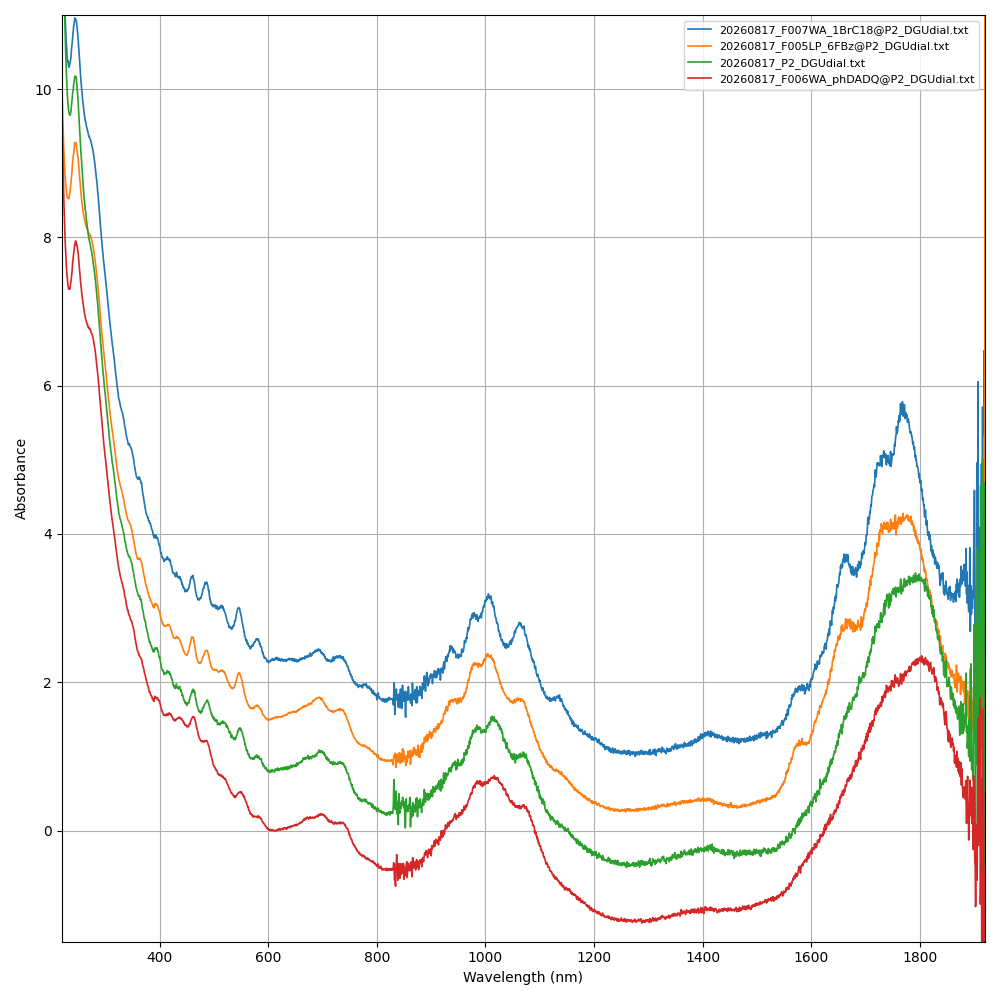

In [46]:
%matplotlib widget
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# For interactive plots in an external window
import matplotlib


# ============================================================
# 1. LOAD UV-VIS-NIR TXT SPECTRA
# ============================================================

txt_folders = [
    r"H:\FUBerlin\Measurements\UVvisNIR\CristianB\20260810_DGUdial_P2_F005_F006_F007",
    r"H:\FUBerlin\Measurements\UVvisNIR\CristianB\20260817_DGUdial_P2_F005_F006_F007_ProperResolution",
]


txt_spectra = {}


for txt_folder in txt_folders:

    print("\nReading folder:")
    print(txt_folder)

    for file in os.listdir(txt_folder):

        if not file.lower().endswith(".txt"):
            continue

        path = os.path.join(txt_folder, file)

        try:

            df = pd.read_csv(
                path,
                sep="\t",
                skiprows=1,
                dtype=str
            )

            df.columns = [
                "Wavelength",
                "Abs"
            ]

            # Clean decimal separators
            df["Wavelength"] = (
                df["Wavelength"]
                .str.strip()
                .str.replace(",", ".", regex=False)
            )

            df["Abs"] = (
                df["Abs"]
                .str.strip()
                .str.replace(",", ".", regex=False)
            )

            # Convert to numbers
            df["Wavelength"] = pd.to_numeric(
                df["Wavelength"],
                errors="coerce"
            )

            df["Abs"] = pd.to_numeric(
                df["Abs"],
                errors="coerce"
            )

            # Remove invalid rows
            df = df.dropna()

            # Sort wavelength
            df = (
                df.sort_values("Wavelength")
                .reset_index(drop=True)
            )

            # Filename is your unique identifier
            txt_spectra[file] = df

            print(
                f"Loaded: {file} "
                f"({len(df)} points)"
            )

        except Exception as e:

            print(
                f"Could not load {file}: {e}"
            )


print("\nAvailable spectra:")

for name in txt_spectra:
    print(name)


# ============================================================
# 2. PLOT FUNCTION
# ============================================================

def PlotSpectra(
        spectra_dict,
        spectra_names,
        offset_step=0.0,
        xmin=None,
        xmax=None,
        ymin=None,
        ymax=None,
        ylabel="Absorbance",
        size = (8, 5),
        linewidth=1.0

):

    plt.figure(figsize = size)

    for i, name in enumerate(spectra_names):

        if name not in spectra_dict:
            print(f"WARNING: {name} not found")
            continue

        df = spectra_dict[name]

        X = df["Wavelength"].values
        Y = df["Abs"].values

        Y_plot = Y + i * offset_step

        plt.plot(
            X,
            Y_plot,
            label=name,
            linewidth=linewidth

        )

    plt.xlabel("Wavelength (nm)")
    plt.ylabel(ylabel)

    if xmin is not None or xmax is not None:
        plt.xlim(xmin, xmax)
    if ymin is not None or ymax is not None:
        plt.ylim(ymin, ymax)
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# ============================================================
# 3. NORMALIZATION FUNCTION
# ============================================================

def NormalizeSpectra(
        spectra_input,
        xmin,
        xmax,
        mode="M"
):

    """
    Normalize spectra.

    M = maximum
    I = integral
    V = valley/minimum
    """

    normalized = {}

    for name, df in spectra_input.items():

        df_norm = df.copy()

        X = df_norm["Wavelength"].values
        Y = df_norm["Abs"].values

        mask = (
            (X >= xmin)
            &
            (X <= xmax)
        )

        X_window = X[mask]
        Y_window = Y[mask]

        if len(X_window) == 0:

            print(
                f"No normalization range for {name}"
            )

            continue

        # ----------------------------------------
        # Maximum normalization
        # ----------------------------------------

        if mode.upper() == "M":

            factor = np.max(Y_window)

        # ----------------------------------------
        # Integral normalization
        # ----------------------------------------

        elif mode.upper() == "I":

            factor = np.trapezoid(
                Y_window,
                X_window
            )

        # ----------------------------------------
        # Valley normalization
        # ----------------------------------------

        elif mode.upper() == "V":

            factor = np.min(Y_window)

        else:

            raise ValueError(
                "Mode must be 'M', 'I', or 'V'"
            )

        if factor == 0:

            print(
                f"Normalization factor is zero for {name}"
            )

            continue

        df_norm["Abs"] = Y / factor

        normalized[name] = df_norm

        print(
            f"Normalized: {name} "
            f"(factor = {factor:.6g})"
        )

    return normalized


# ============================================================
# 4. SELECT YOUR EXPERIMENTAL SPECTRA
# ============================================================

spectra_to_plot = [

    "20260817_F007WA_1BrC18@P2_DGUdial.txt",
    "20260817_F005LP_6FBz@P2_DGUdial.txt",
    "20260817_P2_DGUdial.txt",
    "20260817_F006WA_phDADQ@P2_DGUdial.txt",

]


# ============================================================
# 5. BASELINE SUBTRACTION
# ============================================================

baseline_name = (
    "20260817_Baseline_DOCD2O1pc.txt"
)

baseline = txt_spectra[baseline_name]


def SubtractBaseline(
        spectra_input,
        baseline
):

    corrected_spectra = {}

    baseline_x = baseline["Wavelength"].values
    baseline_y = baseline["Abs"].values

    for name, df in spectra_input.items():

        measured_x = df["Wavelength"].values
        measured_y = df["Abs"].values

        # Interpolate baseline onto measured grid
        baseline_interpolated = np.interp(
            measured_x,
            baseline_x,
            baseline_y
        )

        corrected = df.copy()

        corrected["Abs"] = (
            measured_y
            -
            baseline_interpolated
        )

        corrected_spectra[name] = corrected

        print(
            f"Baseline corrected: {name}"
        )

    return corrected_spectra


# Only select the spectra we actually want
selected_spectra = {
    name: txt_spectra[name]
    for name in spectra_to_plot
    if name in txt_spectra
}


# Apply baseline correction
baseline_corrected_spectra = SubtractBaseline(
    selected_spectra,
    baseline
)


# ============================================================
# 6. LOAD WATER CALIBRATION FILE
# ============================================================

References = r"H:\FUBerlin\Measurements\UVvisNIR\References.csv"

calibration_df = pd.read_csv(
    References,
    sep=",",
    skiprows=2,
    header=None,
    names=[
        "Water_Wavelength",
        "WaterInD2O",

        "Nicodenz_Wavelength",
        "Nicodenz",

        "Empty_Wavelength",
        "Empty_P2",

        "WaterFilled_Wavelength",
        "WaterFilled"
    ]
)


# ============================================================
# 7. CONVERT CALIBRATION TABLE TO SPECTRA DICTIONARY
# ============================================================

calibration_spectra = {}


for i in range(
        0,
        len(calibration_df.columns),
        2
):

    wavelength_column = (
        calibration_df.columns[i]
    )

    absorbance_column = (
        calibration_df.columns[i + 1]
    )

    spectrum_name = absorbance_column

    spectrum = pd.DataFrame({

        "Wavelength": pd.to_numeric(
            calibration_df[wavelength_column],
            errors="coerce"
        ),

        "Abs": pd.to_numeric(
            calibration_df[absorbance_column],
            errors="coerce"
        )

    })

    spectrum = (
        spectrum
        .dropna()
        .sort_values("Wavelength")
        .reset_index(drop=True)
    )

    calibration_spectra[
        spectrum_name
    ] = spectrum


print("\nCalibration spectra:")

for name, df in calibration_spectra.items():

    print(
        f"{name}: {len(df)} points"
    )


# ============================================================
# 8. WATER CALIBRATION SUBTRACTION
# ============================================================

def ApplyCalibrationCorrection(
        spectra_input,
        calibration_spectrum,
        calibration_factors
):

    """
    For each spectrum:

        corrected =
            measured
            -
            factor * water_calibration

    The calibration spectrum is interpolated
    onto the wavelength grid of the measured spectrum.
    """

    corrected_spectra = {}

    calibration_x = (
        calibration_spectrum["Wavelength"].values
    )

    calibration_y = (
        calibration_spectrum["Abs"].values
    )

    for name, df in spectra_input.items():

        # ----------------------------------------
        # Get factor for this spectrum
        # ----------------------------------------

        if name not in calibration_factors:

            print(
                f"WARNING: No water calibration "
                f"factor for {name}"
            )

            continue

        factor = calibration_factors[name]

        # ----------------------------------------
        # Measured spectrum
        # ----------------------------------------

        measured_x = df["Wavelength"].values
        measured_y = df["Abs"].values

        # ----------------------------------------
        # Check wavelength overlap
        # ----------------------------------------

        if (
            measured_x.min() < calibration_x.min()
            or
            measured_x.max() > calibration_x.max()
        ):

            print(
                f"WARNING: {name} extends "
                f"outside calibration range."
            )

            print(
                f"Measured: "
                f"{measured_x.min()} - "
                f"{measured_x.max()} nm"
            )

            print(
                f"Calibration: "
                f"{calibration_x.min()} - "
                f"{calibration_x.max()} nm"
            )

        # ----------------------------------------
        # Interpolate calibration
        # ----------------------------------------

        calibration_interpolated = np.interp(
            measured_x,
            calibration_x,
            calibration_y
        )

        # ----------------------------------------
        # Subtract scaled water spectrum
        # ----------------------------------------

        corrected = df.copy()

        corrected["Abs"] = (
            measured_y
            -
            factor * calibration_interpolated
        )

        corrected_spectra[name] = corrected

        print(
            f"Water corrected: {name} "
            f"(factor = {factor})"
        )

    return corrected_spectra


# ============================================================
# 9. CHOOSE WATER CALIBRATION
# ============================================================

water_calibration = (
    calibration_spectra["WaterInD2O"]
)


# ============================================================
# 10. WATER CALIBRATION FACTORS
# ============================================================

calibration_factors = {



    "20260817_F007WA_1BrC18@P2_DGUdial.txt": 0.2,
    "20260817_F005LP_6FBz@P2_DGUdial.txt": 1.5,
    "20260817_P2_DGUdial.txt": 0,
    "20260817_F006WA_phDADQ@P2_DGUdial.txt": 0.3,

}


# ============================================================
# 11. APPLY WATER CORRECTION
# ============================================================

water_corrected_spectra = (
    ApplyCalibrationCorrection(
        baseline_corrected_spectra,
        water_calibration,
        calibration_factors
    )
)


# ============================================================
# 12. NORMALIZATION
# ============================================================

normalized_spectra = NormalizeSpectra(
    water_corrected_spectra,
#    xmin=600,
#    xmax=800,
#    mode="M"

    xmin=1200,
    xmax=1350,
    mode="V"

 #   xmin=799,
 #   xmax=801,
 #   mode="V"
)


# ============================================================
# 13. FINAL PLOT
# ============================================================

PlotSpectra(
    normalized_spectra,
    spectra_to_plot,
    offset_step=-0.75,
    xmin=220,
    xmax=1920,
    ymin=-1.5,
    ymax=11,
    ylabel="Absorbance",    
    size=(7,7),
    linewidth = 1.2
)

pathFigures = r"H:\FUBerlin\DataAnalysis\UVvisNIR\NT26_PosterFigures_DGUdialSamples"
#plt.gca().set_yticklabels([])
plt.grid(False)

plt.savefig(
    str(pathFigures)+ r"\UVvisNIR_DGUdial.svg",
    dpi=300,
    bbox_inches="tight"
)

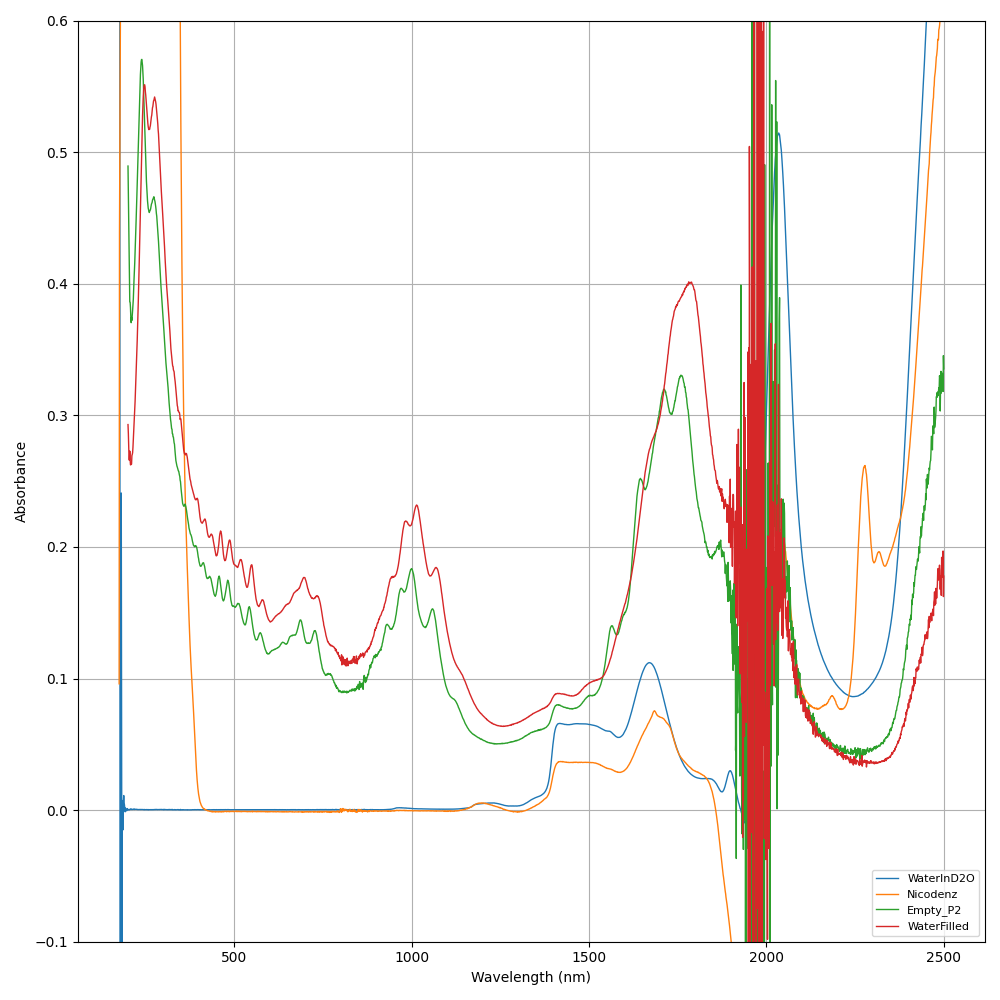

In [41]:
# ==========================
# PLOT CALIBRATION SPECTRA
# ==========================

calibration_to_plot = [
    "WaterInD2O",
    "Nicodenz",
    "Empty_P2",
    "WaterFilled",
]

PlotSpectra(
    calibration_spectra,
    calibration_to_plot,
    offset_step=0.0,
    #xmin=200,
    #xmax=2400,
    ymin=-0.1,
    ymax=0.6,
    ylabel="Absorbance",
    size=(10,10)
)